In [1]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
from data_generator import *
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


In [79]:
from matplotlib.pyplot import grid
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class SimplePolygonEnv(gym.Env):
    """Custom Environment that follows gymnasium interface"""
    
    def __init__(self, grid_dataset):
        super(SimplePolygonEnv, self).__init__()
        
        self.grid_dataset = grid_dataset # Pass your offline dataset here
        self.current_grid_idx = 0
        
        # Assume H=16, W=16 for this example. Change to your actual grid size.
        self.H, self.W = 16, 16 
        
        # ACTION SPACE: 4 Discrete Actions (0: Up, 1: Down, 2: Left, 3: Right)
        self.action_space = spaces.Discrete(4)
        self.action_mapping = {
            0: (-1, 0),  # Up
            1: (1, 0),   # Down
            2: (0, -1),  # Left
            3: (0, 1)    # Right
        }
        
        # OBSERVATION SPACE: The exact 4-Channel tensor you feed your U-Net
        # Shape: (4, H, W), Values between 0.0 and 1.0
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(4, self.H, self.W), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # 1. Load a random grid from your dataset
        self.grid = self.grid_dataset[np.random.randint(len(self.grid_dataset))]
        
        # 2. Spawn agent on a random clear floor tile
        free_cells = np.argwhere(self.grid == 0)
        spawn_idx = np.random.choice(len(free_cells))
        self.agent_pos = tuple(free_cells[spawn_idx])
        self.path = [self.agent_pos]
        
        # 3. Initialize Memory Maps
        self.known_obstacles = np.zeros_like(self.grid, dtype=np.float32)
        self.unseen_map = np.ones_like(self.grid, dtype=np.float32)
        # --- NEW BREADCRUMB MEMORY ---
        self.visit_count = np.zeros_like(self.grid, dtype=np.float32)
        
        self.step_count = 0
        self.max_steps = 256
        
        # 4. Generate initial observation
        obs = self._get_obs()
        
        # Gymnasium v0.26+ requires returning (observation, info_dict)
        return obs, {}

    def step(self, action):
        self.step_count += 1
        
        if isinstance(action, np.ndarray):
            action = action.item()
        # 1. Attempt to move the agent
        dr, dc = self.action_mapping[action]
        r, c = self.agent_pos
        nr, nc = r + dr, c + dc
        
        reward = -0.1 # Base time penalty (punishes dithering/hesitation)
        
        # 2. Check collision
        if 0 <= nr < self.H and 0 <= nc < self.W and self.grid[nr, nc] == 0:
            # Valid move
            self.agent_pos = (nr, nc)
            self.path.append(self.agent_pos)
            
            # --- THE REVISIT PENALTY ---
            # If we have been here before, penalize it heavily. 
            # 1st visit = 0 penalty. 2nd visit = -0.1. 3rd visit = -0.2. etc.
            reward -= (self.visit_count[nr, nc] * 0.1)
            self.visit_count[nr, nc] += 1
            # ---------------------------
        else:
            reward -= 5 # Wall collision
            self.path.append(self.agent_pos) # Even if we hit a wall, we "visit" that cell for LOS purposes

        # 3. Update Maps & Calculate New Information
        previous_unseen_count = self.unseen_map.sum()
        obs = self._get_obs() # This calls your LOS and Grazing functions
        current_unseen_count = self.unseen_map.sum()
        
        # 4. Reward Shaping: Reward the agent for discovering new floor
        cells_revealed = previous_unseen_count - current_unseen_count
        if cells_revealed >= 0:
            reward += 1.0 + (cells_revealed * 5.0)
            
        # 5. Check Termination Conditions
        terminated = False
        truncated = False
        
        # 2. The Exact Termination Condition
        unseen_floor_count = np.sum(self.unseen_map[self.grid == 0])
        
        # Did we explore everything?
        if unseen_floor_count == 0:  
            terminated = True
            # --- THE SPEED BONUS ---
            # Max possible steps is self.max_steps. We reward the agent for unused time.
            steps_remaining = self.max_steps - self.step_count
            
            # Base completion (+10) plus a scaling bonus for speed (e.g., +0.1 per saved step)
            speed_bonus = steps_remaining * 0.1
            reward += (10.0 + speed_bonus)
            
        # Did we run out of time? (e.g., trapped in a loop)
        if self.step_count >= self.max_steps:
            truncated = True

        return obs, float(reward), terminated, truncated, {"path": self.path}

    def _get_obs(self):
        """Builds the 3-channel state tensor identically to your U-Net"""
        agent_layer = np.zeros_like(self.grid, dtype=np.float32)
        agent_layer[self.agent_pos] = 1.0
        
        # NOTE: Call your exact LOS functions here
        expanded_los_ = get_LOS4_visibility_map(self.grid, self.path)
        expanded_los = apply_grazing_los(self.grid, expanded_los_)
        
        # For boilerplate, assuming expanded_los is calculated:
        self.unseen_map[expanded_los == 1] = 0.0
        visible_walls = expanded_los & (self.grid == 1)
        self.known_obstacles[visible_walls] = 1.0
        # Normalize the visit count so the neural network can read it safely [0.0 to 1.0]
        # (Assuming it rarely visits a single cell more than 10 times if exploring optimally)
        visit_heatmap = np.clip(self.visit_count / 10.0, 0.0, 1.0)
        
        state_tensor = np.stack([
            self.known_obstacles, 
            agent_layer, 
            self.unseen_map, 
            visit_heatmap # <-- The new 4th channel
        ], axis=0)
        
        return state_tensor

In [80]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from autoregressive_unet import ResidualConv

class CustomGridCNN(BaseFeaturesExtractor):
    """
    A custom CNN tailored for tiny 16x16 grids.
    """
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 256):
        super(CustomGridCNN, self).__init__(observation_space, features_dim)
        
        n_input_channels = observation_space.shape[0]
        
        self.cnn = nn.Sequential(
            # 16x16 -> 16x16
            nn.Conv2d(n_input_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # 16x16 -> 8x8
            nn.MaxPool2d(2),
            # 8x8 -> 8x8
            nn.Conv2d(16, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            # 8x8 -> 4x4
            nn.MaxPool2d(2),
            nn.Flatten(),
        )

        # Compute shape by doing one forward pass with dummy data
        with torch.no_grad():
            dummy_tensor = torch.as_tensor(observation_space.sample()[None]).float()
            n_flatten = self.cnn(dummy_tensor).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim), 
            nn.ReLU()
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        return self.linear(self.cnn(observations))

Generated Grid:


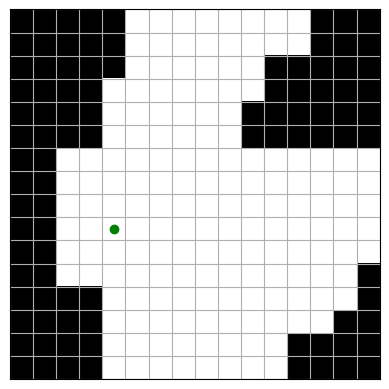

In [81]:
# Generate a random grid
gen = WRPDataGenerator(16, 16)
# grid, start = gen.generate_valid_grid(density=5)
grid, start = gen.generate_simple_polygon_grid()
print("Generated Grid:")

plot_grid(grid, start)


In [82]:
N = 500
grid_dataset = []
for _i in range(N):
    grid, start = gen.generate_simple_polygon_grid()
    grid_dataset.append(grid)
np.array(grid_dataset).shape

(500, 16, 16)

In [83]:
# import stable_baselines3
# stable_baselines3.common.env_checker.check_env(SimplePolygonEnv(grid_dataset=grid_dataset), warn=True)

In [ ]:
from stable_baselines3 import PPO

# Tell SB3 to use your CustomGridCNN instead of NatureCNN
policy_kwargs = dict(
    features_extractor_class=CustomGridCNN,
    features_extractor_kwargs=dict(features_dim=256),
)

env = SimplePolygonEnv(grid_dataset=grid_dataset)

print("Starting PPO Training with Custom CNN...")
model = PPO("CnnPolicy", env, policy_kwargs=policy_kwargs, verbose=1, learning_rate=0.0003)

model.learn(total_timesteps=500_000)

Starting PPO Training with Custom CNN...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 256      |
|    ep_rew_mean     | 897      |
| time/              |          |
|    fps             | 768      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 256         |
|    ep_rew_mean          | 759         |
| time/                   |             |
|    fps                  | 459         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013276815 |
|    clip_fraction        | 0.0472      |
|    clip_range      

In [38]:
import numpy as np
from stable_baselines3 import PPO

# # 1. Load the RAW test dataset (Ground truth grids, not X_test/y_test tensors)
# # Assuming you have 750 raw test grids based on your previous data
# raw_test_grids = np.load("data/raw_simple_polygons_test.npy") 

# 2. Initialize the environment with the TEST data
eval_env = SimplePolygonEnv(grid_dataset=grid_dataset)

# 3. Load the trained model
# Replace with your actual saved model path
# model = PPO.load("ppo_baseline_agent")

ppo_path_lengths = []
success_count = 0

print(f"Evaluating PPO Baseline on {len(grid_dataset)} test environments...")

for i in range(len(grid_dataset)):
    # Force the environment to use the specific test grid sequentially
    eval_env.grid_dataset = [grid_dataset[i]] 
    obs, info = eval_env.reset()
    
    done = False
    steps_taken = 0
    
    while not done:
        # deterministic=True forces the agent to take the action with the highest probability
        action, _states = model.predict(obs, deterministic=True)
        
        obs, reward, terminated, truncated, info = eval_env.step(action.item())
        steps_taken += 1
        
        if terminated or truncated:
            done = True
            ppo_path_lengths.append(steps_taken)
            if terminated:
                success_count += 1
            
    if (i + 1) % 50 == 0:
        print(f"Evaluated {i + 1}/{len(grid_dataset)} grids...")

# --- THE FINAL METRICS ---
print("\n--- PPO Baseline Results ---")
print(f"Total Successes (Explored 100%): {success_count} / {len(grid_dataset)}")
print(f"Success Rate: {(success_count / len(grid_dataset)) * 100:.2f}%")
print(f"Average Path Length (including timeouts): {np.mean(ppo_path_lengths):.2f}")

Evaluating PPO Baseline on 500 test environments...
Evaluated 50/500 grids...
Evaluated 100/500 grids...
Evaluated 150/500 grids...
Evaluated 200/500 grids...
Evaluated 250/500 grids...
Evaluated 300/500 grids...
Evaluated 350/500 grids...
Evaluated 400/500 grids...
Evaluated 450/500 grids...
Evaluated 500/500 grids...

--- PPO Baseline Results ---
Total Successes (Explored 100%): 0 / 500
Success Rate: 0.00%
Average Path Length (including timeouts): 256.00


Agent failed to explore the entire grid within the step limit.


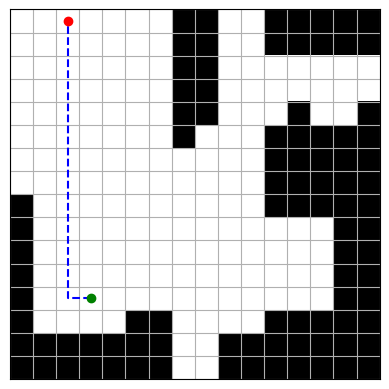

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO

# Load a single grid for visualization
eval_env.grid_dataset = [grid_dataset[0]] 
obs, info = eval_env.reset()
grid = eval_env.grid

done = False
while not done:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    if terminated or truncated:
        done = True
        if terminated:
            print("Agent successfully explored the entire grid!")
        else:
            print("Agent failed to explore the entire grid within the step limit.")

# Extract the path it took
path = info['path']

plot_path(grid, path)

In [78]:
path

[(np.int64(12), np.int64(3)),
 (np.int64(12), np.int64(2)),
 (np.int64(11), np.int64(2)),
 (np.int64(10), np.int64(2)),
 (np.int64(9), np.int64(2)),
 (np.int64(8), np.int64(2)),
 (np.int64(7), np.int64(2)),
 (np.int64(6), np.int64(2)),
 (np.int64(5), np.int64(2)),
 (np.int64(4), np.int64(2)),
 (np.int64(3), np.int64(2)),
 (np.int64(2), np.int64(2)),
 (np.int64(1), np.int64(2)),
 (np.int64(0), np.int64(2))]

In [133]:
len(path)

29